In [160]:
import pandas as pd
import os

def plot_pathway_panels(
    cts,
    pathway_genes,
    module_name="Pathway",
    results_root="../results/age",
    age_key="mean_cpm_age_60",
    expr_min=30,
    p_cutoff=0.1,
    n_cols=3,
    shared_xlim=None,  # e.g. (-1, 6) or None for auto
):
    """
    Multi-panel barplots of fold-change for a gene module across cell types.

    pathway_genes : list of str
        Genes to include for this pathway/module.
    """

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import os, math

    n_ct = len(cts)
    n_rows = math.ceil(n_ct / n_cols)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(n_cols * 5.5, n_rows * 5.5),
        sharex=True
    )
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    # infer which file to load
    age_suffix = "60" if "60" in age_key else "21"

    for i, ct in enumerate(cts):
        ax = axes[i]
        fn = os.path.join(results_root, ct, f"simple_effect_age_{age_suffix}.csv")

        if not os.path.exists(fn):
            print(f"Skipping {ct}: file not found at {fn}")
            ax.axis("off")
            continue

        df = pd.read_csv(fn, index_col=0)
        df_t = df.T  # rows = metrics, cols = genes

        # intersect this module with available genes
        genes_here = [g for g in pathway_genes if g in df_t.columns]
        if not genes_here:
            print(f"Skipping {ct}: none of {module_name} genes found.")
            ax.axis("off")
            continue

        # slice to pathway genes
        df_mod = df_t[genes_here]

        # confirm we have both the age_key row and log2FC row
        required_rows = ["log2FC_mtDSB_vs_control", "pvalue_mtDSB_vs_control", age_key]
        if any(r not in df_mod.index for r in required_rows):
            print(f"{ct}: missing required rows in table, skipping.")
            ax.axis("off")
            continue

        # expression filter
        df_filt = df_mod.T[df_mod.T[age_key] > expr_min].T
        if df_filt.shape[1] == 0:
            print(f"{ct}: no {module_name} genes pass expr_min={expr_min} for {age_key}")
            ax.axis("off")
            continue

        # tidy table for plotting
        plot_df = pd.DataFrame({
            "gene": df_filt.columns,
            "log2FC": df_filt.loc["log2FC_mtDSB_vs_control"].values,
            "pval": df_filt.loc["pvalue_mtDSB_vs_control"].values,
            "expr": df_filt.loc[age_key].values,
        })

        # flag significant-ish
        plot_df["sig_flag"] = plot_df["pval"] < p_cutoff

        # rank by effect size
        plot_df = plot_df.sort_values("log2FC", ascending=True)

        # colors: red if sig, gray if not
        colors = ["#b30000" if sig else "#cccccc" for sig in plot_df["sig_flag"]]

        # plot bars
        ax.barh(
            plot_df["gene"],
            plot_df["log2FC"],
            color=colors,
            edgecolor="black",
            linewidth=0.6,
        )

        # 0 line
        ax.axvline(0, color="k", lw=0.8, ls="--")

        # titles/labels
        ax.set_title(ct.replace("_", " "), fontsize=11)
        ax.set_xlabel("log₂FC (mtDSB vs control)")
        ax.set_ylabel("Gene" if i % n_cols == 0 else "")

        # x-limits and label placement
        if isinstance(shared_xlim, tuple):
            ax.set_xlim(shared_xlim)
            x_text = shared_xlim[1] - 0.5
        else:
            x_max = max(plot_df["log2FC"].max(), 0)
            ax.set_xlim(-1, x_max + 1.5)
            x_text = x_max + 0.4

        # annotate each bar with fold-change multiplier and expression
        for _, row in plot_df.iterrows():
            fc_mult = 2 ** row["log2FC"]
            label = f"{fc_mult:>4.1f}× | {row['expr']:>5.0f}"
            ax.text(
                x_text,
                row["gene"],
                label,
                va="center",
                ha="left",
                fontsize=7,
                fontfamily="monospace",
            )

    # turn off any empty axes in the grid
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    # nice supertitle
    fig.suptitle(
        f"{module_name} across cell types\n"
        f"(label = fold-change × | {age_key.replace('_',' ')} ; p<{p_cutoff})",
        fontsize=13,
        y=1.02,
    )

    plt.tight_layout()
    plt.show()

In [56]:
cts = os.listdir('../results/age/') 

In [58]:
# Original combined ISR list
isr_all = [
    "Atf4", "Atf5", "Ddit3", "Trib3", "Asns", "Gadd45g", "Chac1", "Ppp1r15a",
    "Hspa5", "Herpud1", "Xbp1", "Atf6", "Ero1lb", "Dnajb9", "Pdia4", "Pdia6",
    "Hspd1", "Hspe1", "Lonp1", "Clpp", "Dnajc19", "Yme1l1", "Mtf1", "Sod2",
    "Hif1a", "Hmox1", "Bbc3", "Bax", "Bcl2l11", "Cdkn1a", "Gadd45b",
    "Tnfaip3", "Nfkb2", "Rela", "Ccl2", "Cxcl10", "Il6"
]

# Genes missing in adata (from your KeyError)
missing_genes = [
    "Asns", "Gadd45b", "Xbp1", "Pdia6", "Clpp", "Dnajc19", "Lonp1",
    "Ppp1r15a", "Yme1l1", "Chac1", "Gadd45g", "Pdia4", "Herpud1",
    "Hspe1", "Dnajb9", "Il6"
]

# Remove missing ones
isr_filtered = [g for g in isr_all if g not in missing_genes]

print(f"Filtered ISR gene list ({len(isr_filtered)} genes):")
print(isr_filtered)

Filtered ISR gene list (21 genes):
['Atf4', 'Atf5', 'Ddit3', 'Trib3', 'Hspa5', 'Atf6', 'Ero1lb', 'Hspd1', 'Mtf1', 'Sod2', 'Hif1a', 'Hmox1', 'Bbc3', 'Bax', 'Bcl2l11', 'Cdkn1a', 'Tnfaip3', 'Nfkb2', 'Rela', 'Ccl2', 'Cxcl10']


In [121]:
sub = df.sort_values(by = 'log2FC_mtDSB_vs_control', ascending = False)

In [148]:
def filter_genes_in_data(data, genes):
    """
    Return only genes from the input list that are present in the given data.
    
    Parameters
    ----------
    data : AnnData | pandas.DataFrame
        The data object containing gene names either in:
        - adata.var_names (for AnnData)
        - df.index (for DataFrame)
    genes : list of str
        List of gene names to filter.

    Returns
    -------
    list of str
        Filtered list containing only genes found in the data.
    """
    import pandas as pd
    from anndata import AnnData

    # Determine available gene names
    if isinstance(data, AnnData):
        available = set(data.var_names)
        src = "adata.var_names"
    elif isinstance(data, pd.DataFrame):
        available = set(data.index)
        src = "df.index"
    else:
        raise TypeError("Input must be AnnData or pandas DataFrame")

    found = [g for g in genes if g in available]
    missing = [g for g in genes if g not in available]

    print(f"✅ {len(found)} genes found in {src}.")
    if missing:
        print(f"⚠️ {len(missing)} genes not found and removed: {', '.join(missing)}")

    return found

In [152]:
isr_extended = [
    # canonical ISR
    "Atf4", "Atf5", "Ddit3", "Trib3", "Ppp1r15a", "Asns", "Gadd45g", "Chac1",
    # UPR-related
    "Hspa5", "Herpud1", "Xbp1", "Atf6", "Ero1lb", "Dnajb9", "Pdia4", "Pdia6",
    # Mito-UPR and oxidative stress
    "Hspd1", "Hspe1", "Lonp1", "Clpp", "Yme1l1", "Mtf1", "Sod2", "Hmox1",
    # Downstream ISR transcriptional/apoptotic
    "Bbc3", "Bax", "Bcl2l11", "Cdkn1a", "Gadd45b", "Gadd45a", "Eif4ebp1",
    # ISR–metabolic interface genes (from your image)
    "Nupr1", "Slc7a5", "Slc7a11", "Psat1", "Aldh18a1", "Ccnd2", "G0s2", "Tnc"
]

In [156]:
clic_isr_genes = [
    "Aars", "Aldh18a1", "Adm2", "Aldh1l2", "Angptl6", "Arhgef2", "Asns", "Atf3", "Atf4", "Atf5",
    "Atf6", "Car6", "Ccnb1ip1", "Ccpg1", "Cdkn1a", "Cebpb", "Chac1", "Ciart", "Clic4", "Cln8",
    "Crls1", "Cth", "Cyb5r1", "Cyb5r2", "Ddit3", "Ddit4", "Derl1", "Eif1", "Eif1b", "Eif2s2",
    "Eif3c", "Eif4ebp1", "Epb41l4a", "Ero1l", "Fads3", "Fam129a", "Fam89a", "Fgf21", "Gadd45a",
    "Gars", "Gdf15", "Ghitm", "Glce", "Gnpnat1", "Got1", "Gpt2", "Gtpbp2", "Hax1", "Herpud1",
    "Hmox1", "Hoxa9", "Hspa9", "Iars", "Ifrd1", "Idh1", "Krtcap2", "Lars", "Leprotl1", "Lonp1",
    "Mars", "Mdfic", "Mtbp", "Mthfd1l", "Mthfd2", "Nars", "Nfe2l1", "Nfil3", "Nop14", "Nupr1",
    "Otub2", "Paqr3", "Pck2", "Pfkp", "Phf10", "Phgdh", "Pim1", "Plpp4", "Ppp1r15a", "Psat1",
    "Psph", "Pvr", "Pycr1", "Rars", "Rgs16", "Rhbdd1", "Sars", "Scpep1", "Sesn2", "Shmt2",
    "Siah2", "Slc1a4", "Slc1a5", "Slc25a33", "Slc3a2", "Slc6a9", "Slc7a1", "Slc7a3", "Slc7a5",
    "Slc7a11", "Soat2", "Steap1", "St6galnac1", "Tars", "Tbc1d31", "Tcea1", "Tgif1", "Trib3",
    "Tsc22d3", "Ubr2", "Uhrf1bp1", "Vegfa", "Wars", "Xpot", "Yars", "Ydjc", "Znfx1"
]

In [157]:
# For DataFrame
genes_filtered = filter_genes_in_data(sub, clic_isr_genes)

✅ 40 genes found in df.index.
⚠️ 76 genes not found and removed: Aars, Aldh18a1, Adm2, Angptl6, Arhgef2, Asns, Atf3, Car6, Ccnb1ip1, Ccpg1, Cebpb, Chac1, Crls1, Cyb5r1, Cyb5r2, Derl1, Eif1, Eif1b, Eif3c, Fads3, Fam89a, Ghitm, Glce, Gnpnat1, Got1, Hax1, Herpud1, Iars, Ifrd1, Krtcap2, Lars, Leprotl1, Lonp1, Mars, Mdfic, Mtbp, Mthfd1l, Mthfd2, Nars, Nop14, Nupr1, Otub2, Paqr3, Pck2, Phgdh, Plpp4, Ppp1r15a, Psph, Pvr, Pycr1, Rars, Rgs16, Rhbdd1, Sars, Scpep1, Shmt2, Slc1a4, Slc1a5, Slc25a33, Slc3a2, Slc7a1, Slc7a3, Slc7a5, Slc7a11, Soat2, St6galnac1, Tars, Tbc1d31, Tcea1, Tgif1, Ubr2, Uhrf1bp1, Wars, Xpot, Ydjc, Znfx1


In [158]:
sub.loc[genes_filtered].sort_values(by = 'log2FC_mtDSB_vs_control', ascending = False)

,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Trib3,398.099298,5.097241,1.446544,3.523738,0.000426,0.079551,40.708045,1.0,3.441546,77.974544,37.903070,43.513019
Gdf15,107.993546,4.729959,1.449586,3.262971,0.001103,0.128173,11.419832,1.0,1.050444,21.789219,11.603397,11.236267
Cdkn1a,628.630468,3.785308,1.185932,3.191842,0.001414,0.142436,52.241053,1.0,10.017510,94.464596,36.528629,67.953478
Eif4ebp1,72.987545,2.729375,0.932636,2.926517,0.003428,0.216584,6.264428,1.0,1.588289,10.940567,4.631875,7.896981
Aldh1l2,150.164460,1.761861,0.721468,2.442050,0.014604,0.459412,17.178513,1.0,11.440690,22.916337,18.338009,16.019017
Atf5,2941.005557,1.565861,0.532380,2.941245,0.003269,0.212228,274.071326,1.0,151.887954,396.254699,233.966769,314.175883
Pim1,17.025201,1.424337,0.601617,2.367514,0.017908,0.503271,1.697688,1.0,1.295565,2.099811,1.599220,1.796156
Gadd45a,294.037071,1.291805,0.609395,2.119817,0.034021,0.618448,25.710475,1.0,16.486335,34.934616,20.011163,31.409787
Sesn2,900.001307,1.151951,0.325981,3.533800,0.000410,0.079551,81.380618,1.0,49.493504,113.267732,66.749758,96.011478
Ddit3,1920.128068,0.799359,0.236360,3.381956,0.000720,0.097702,179.604772,1.0,135.741768,223.467776,155.313301,203.896244


In [123]:
sub[sub.mean_cpm_age_60 > 30].head(50)

,baseMean,log2FC_mtDSB_vs_control,lfcSE_mtDSB_vs_control,stat,pvalue_mtDSB_vs_control,padj_mtDSB_vs_control,mean_cpm_all,detect_rate_all,mean_cpm_cond_control,mean_cpm_cond_mtDSB,mean_cpm_age_21,mean_cpm_age_60
Trib3,398.099298,5.097241,1.446544,3.523738,4.255040e-04,0.079551,40.708045,1.0,3.441546,77.974544,37.903070,43.513019
Cd40,333.356408,4.856463,1.522588,3.189611,1.424645e-03,0.142436,27.079856,1.0,2.229782,51.929929,17.499788,36.659923
Cdkn1a,628.630468,3.785308,1.185932,3.191842,1.413687e-03,0.142436,52.241053,1.0,10.017510,94.464596,36.528629,67.953478
Nmu,12317.983442,2.947045,1.816924,1.621996,1.048041e-01,0.920060,1227.510327,1.0,394.466837,2060.553816,1091.350455,1363.670198
Serpina3n,1601.121172,2.561028,0.923666,2.772678,5.559717e-03,0.290182,130.608475,1.0,46.908607,214.308343,87.320308,173.896641
Myc,438.656490,1.886191,0.699761,2.695479,7.028752e-03,0.316547,41.892175,1.0,19.919715,63.864635,36.630116,47.154234
Pkd2l1,795.437321,1.805113,0.880094,2.051046,4.026243e-02,0.647354,93.661028,1.0,51.574561,135.747495,102.487324,84.834733
Ccnd1,1269.982337,1.801725,0.650447,2.769979,5.605993e-03,0.290182,133.409766,1.0,60.808636,206.010896,130.688279,136.131252
Igfbp3,350.156177,1.736234,0.661408,2.625057,8.663437e-03,0.352185,33.350778,1.0,15.948636,50.752920,29.844497,36.857060
Atf5,2941.005557,1.565861,0.532380,2.941245,3.268960e-03,0.212228,274.071326,1.0,151.887954,396.254699,233.966769,314.175883


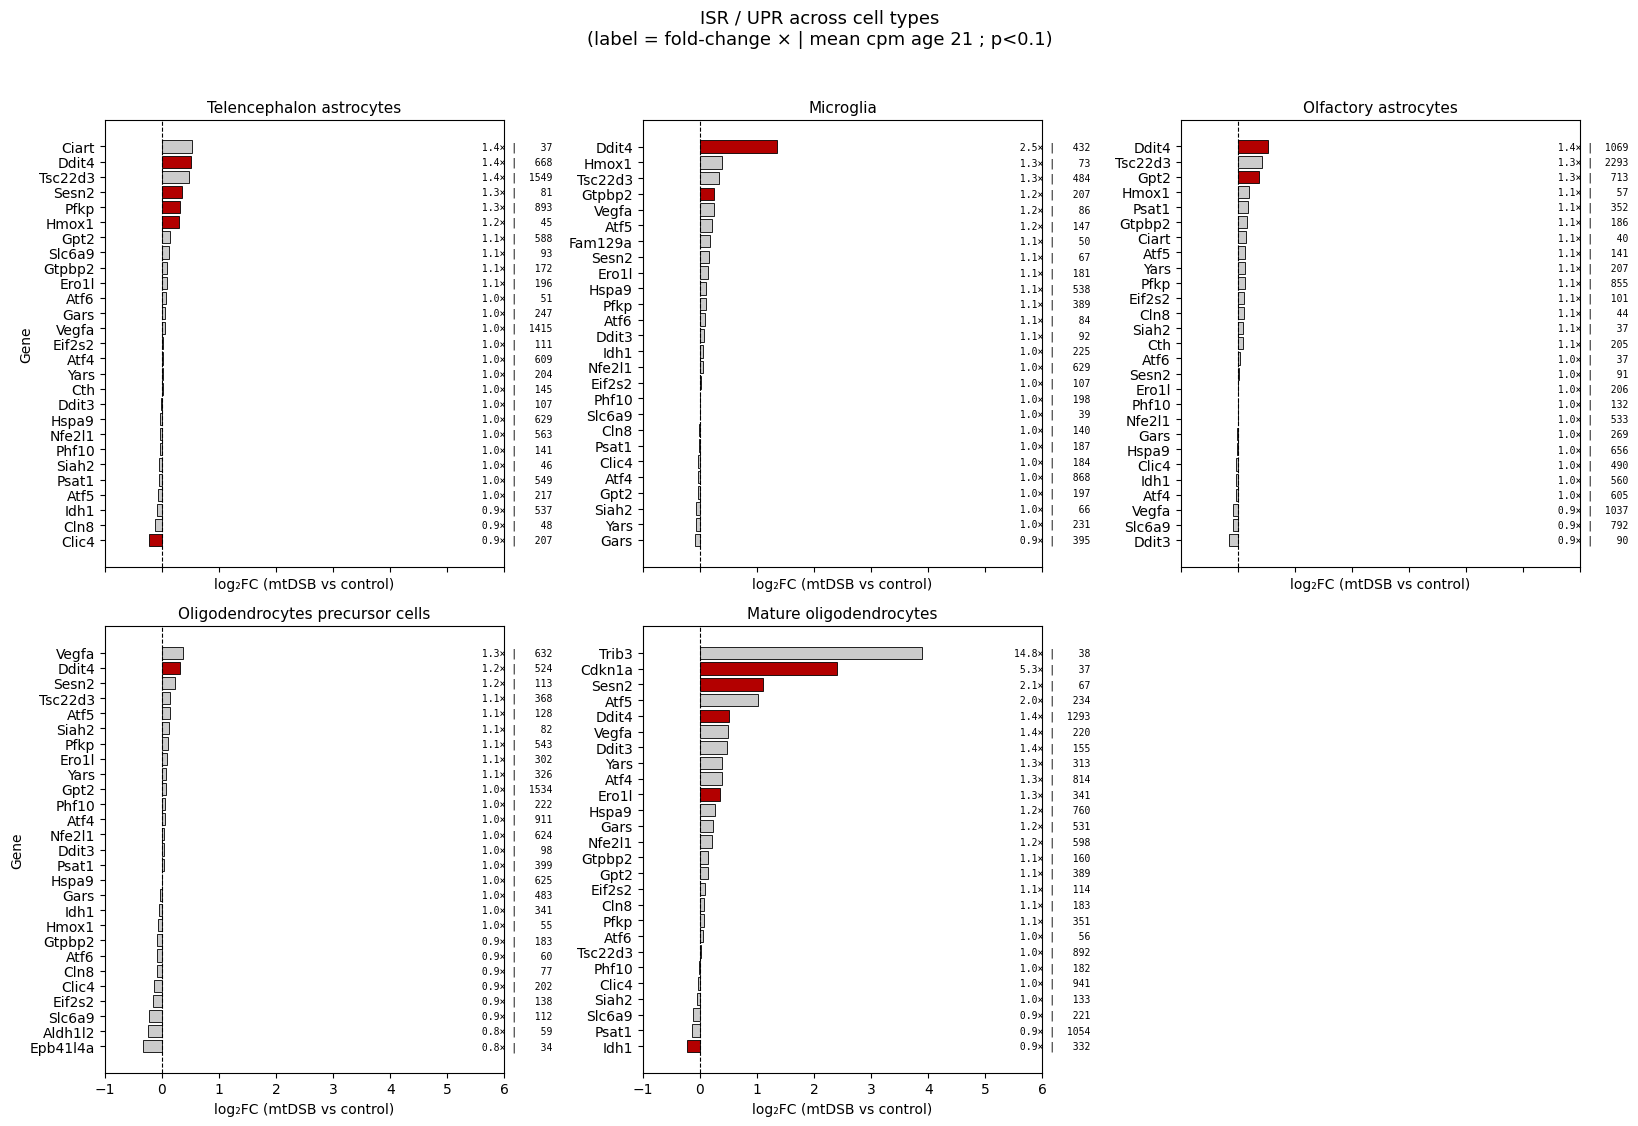

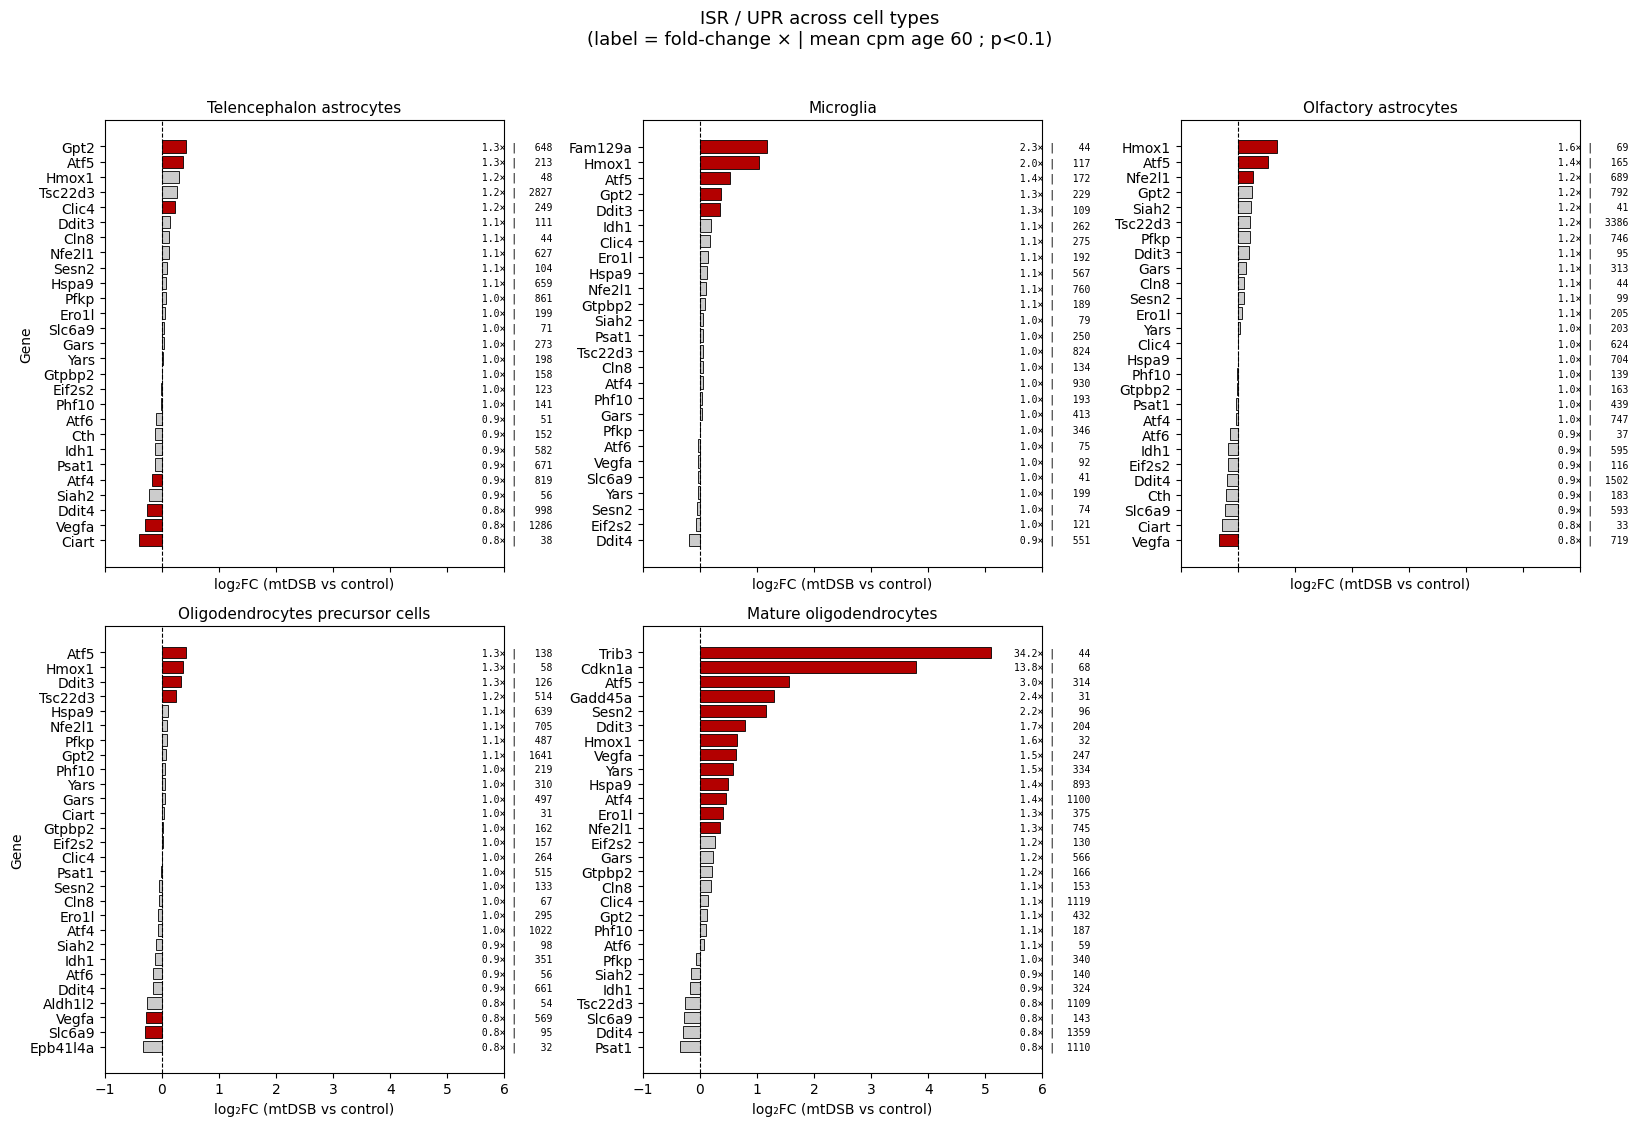

In [159]:
plot_pathway_panels(
    cts,
    pathway_genes=genes_filtered,        # or isr_filtered if you like your curated set
    module_name="ISR / UPR",
    age_key="mean_cpm_age_21",
    shared_xlim=(-1, 6),
    expr_min=30,
    p_cutoff=0.1
)
plot_pathway_panels(
    cts,
    pathway_genes=genes_filtered,        # or isr_filtered if you like your curated set
    module_name="ISR / UPR",
    age_key="mean_cpm_age_60",
    shared_xlim=(-1, 6),
    expr_min=30,
    p_cutoff=0.1
)

# SUMMARY

## 1. 🧬 Integrated Stress Response (ISR) and Unfolded Protein Response (UPR) in mtDNA DSB Oligodendrocyte Model

## Context
This dataset originates from a mouse model in which **oligodendrocytes (OLs)** harbor **double-strand breaks (DSBs) in mitochondrial DNA (mtDNA)**.  
These DSBs were induced at either **postnatal day 21 (P21)** or **postnatal day 60 (P60)**, corresponding to a **juvenile vs. mature CNS environment**.  
Downstream analyses assessed the transcriptional consequences of mtDNA damage across major glial cell types.

Mitochondrial DNA breaks are known to impair oxidative phosphorylation and redox balance, potentially activating the **mitochondrial unfolded protein response (UPR^mt)** and the **integrated stress response (ISR)** — two converging pathways that coordinate translation attenuation, chaperone induction, and cell-fate reprogramming.

---

## Summary of Findings

### **P21 (juvenile induction)**
- **ISR activation is modest and cell-restricted.**  
  Only **mature oligodendrocytes (OLs)** show a clear upregulation of ISR genes such as  
  **Trib3**, **Cdkn1a (p21)**, **Atf5**, and **Ddit3 (CHOP)**.  
- **Other glial populations** (astrocytes, microglia, OPCs) exhibit little or no transcriptional ISR activation.  
- Expression levels of chaperones (e.g. *Hspa5*, *Hspd1*) and redox regulators (*Hmox1*, *Sod2*) remain near baseline.  
- Interpretation: **Developing CNS** has limited ISR induction despite mtDNA damage, possibly reflecting higher intrinsic proteostatic or metabolic resilience.

---

### **P60 (adult induction)**
- **Robust and cell-type-specific ISR activation**, most pronounced in **mature oligodendrocytes**.  
  - Strong upregulation of **Trib3**, **Cdkn1a**, **Atf5**, **Ddit3**, **Atf4**, and **Hmox1**.  
  - Induction of **Hspa5 (BiP)** and **Hspd1 (HSP60)** indicates engagement of both **ER-UPR** and **mitochondrial UPR** arms.  
- **Astrocytes and microglia** show mild ISR signatures (e.g. *Hmox1*, *Atf5*) but no large-scale transcriptional remodeling.  
- **OPCs** upregulate a limited subset (notably *Atf5*, *Hspa5*), consistent with partial stress signaling but not full ISR activation.  
- Interpretation: **Mature OLs are uniquely sensitive** to mitochondrial DNA damage, coupling oxidative stress and proteostatic imbalance to a coordinated ISR/UPR program.

---

## 🧩 Biological Interpretation

- **Mitochondrial dysfunction** likely initiates ISR via the **DELE1–HRI–eIF2α–ATF4 axis**, linking impaired oxidative phosphorylation to translational control.
- The resulting ISR reprograms OLs toward a **protective yet energy-limited state**, characterized by:
  - Reduced protein synthesis (via eIF2α phosphorylation),
  - Increased chaperone expression (*Hspa5*, *Hspd1*),
  - Upregulation of redox defenses (*Hmox1*, *Sod2*),
  - Induction of pro-apoptotic or growth-arrest genes (*Ddit3*, *Trib3*, *Cdkn1a*).
- The magnitude of this response **increases with age**, indicating that mitochondrial stress signaling is more deleterious in the adult CNS.

---

## 🧠 Summary Visualization
The barplots below illustrate log₂ fold changes for ISR/UPR genes across major glial cell types at each age:

| Induction Age | ISR / UPR Signature |
|----------------|--------------------|
| **P21** | Subtle ISR activation limited to mature OLs |
| **P60** | Strong, coordinated ISR/UPR induction in mature OLs; mild activation in astrocytes and microglia |

---

## ✳️ Key Takeaway
**Mitochondrial DNA damage in oligodendrocytes activates the Integrated Stress Response in an age- and cell-type-dependent manner.**  
While juvenile OLs mount a mild adaptive stress response, adult OLs engage a full ISR–UPR transcriptional program, highlighting **age-related vulnerability of mitochondrial proteostasis** in the myelinating lineage.

---

*Modules plotted: ISR / UPR genes (Atf4, Atf5, Ddit3, Trib3, Cdkn1a, Hspa5, Hspd1, Hmox1, Atf6, Rela, etc.).*

## 2. 🧬 The Dual Role of the Integrated Stress Response (ISR) in Myelinating Cells

## Context
Myelinating cells — **oligodendrocytes (CNS)** and **Schwann cells (PNS)** — are among the most metabolically and biosynthetically active cell types in the body.  
They synthesize vast amounts of **myelin proteins and lipids**, continuously challenging their **endoplasmic reticulum (ER)** and **mitochondrial** protein-folding capacity.  
As a result, these cells live close to their **proteostatic and energetic limits**, and even subtle perturbations can trigger **stress response programs** such as the **Unfolded Protein Response (UPR)** and the **Integrated Stress Response (ISR)**.

---

## ISR/UPR Activation in Myelinating Cells
Because myelin synthesis places a heavy burden on both ER folding and mitochondrial energy production:

- **ER stress** (due to misfolded or aggregated myelin proteins) activates **PERK**, initiating the ER branch of the UPR.  
- **Mitochondrial dysfunction** (e.g., impaired oxidative phosphorylation or ROS accumulation) activates **HRI** and **DELE1–ATF4 signaling**, feeding into the ISR.  
- Both converge on **phosphorylation of eIF2α**, reducing global translation while selectively enhancing stress-response transcription factors (**ATF4**, **ATF5**, **CHOP/Ddit3**).

Hence, **UPR and ISR are often co-activated** in myelinating cells — a reflection of their intertwined proteostatic and metabolic control.

---

## Adaptive vs. Maladaptive ISR
The role of the ISR in myelinating disorders is **context-dependent**:

| ISR Mode | Condition | Outcome |
|-----------|------------|----------|
| 🩹 **Adaptive ISR** | Transient or moderate stress (e.g., amino acid limitation, temporary ER load) | Protects OLs by reducing translation, upregulating chaperones (*Hspa5*, *Hspd1*), and restoring proteostasis. |
| 💀 **Maladaptive ISR** | Chronic or unresolved stress (e.g., mitochondrial dysfunction, oxidative damage, persistent misfolded proteins) | Drives growth arrest and apoptosis via *Ddit3 (CHOP)*, *Trib3*, *Cdkn1a*, and *Bax*, leading to demyelination and white matter loss. |

In particular, **GCN2-mediated ISR** has been shown to *protect* oligodendrocytes during **branched-chain amino acid deficiency**, whereas sustained activation of **PERK–ATF4–CHOP** signaling is *detrimental* in chronic myelination disorders.

---

## Connection to the mtDNA DSB Model
In the current model, **oligodendrocytes harbor mitochondrial DNA double-strand breaks (mtDSBs)** induced at either **postnatal day 21 (P21)** or **postnatal day 60 (P60)**:

- At **P21**, ISR activation is modest and largely confined to mature oligodendrocytes, suggesting a **transient, adaptive response**.  
- At **P60**, ISR/UPR engagement is robust, featuring strong induction of **Atf4, Atf5, Ddit3, Trib3, Cdkn1a, Hspa5, and Hspd1**, indicative of **chronic mitochondrial stress** and **maladaptive ISR signaling**.  
- This mirrors findings from myelination disorders, where **energy deficits and protein misfolding** reinforce each other to sustain ISR activation.

---

## Mechanistic Overview

```text
High myelin synthesis → ER protein load ↑ → UPR (PERK–ATF4)
                      → amino acid demand ↑ / ATP use ↑ → GCN2 / HRI activation
Mitochondrial DNA damage → DELE1–HRI–eIF2α → ATF4 / CHOP induction
→ ISR activation

• Acute ISR: translation pause + chaperone induction (protective)
• Chronic ISR: CHOP, Trib3, Cdkn1a → apoptosis / demyelination

## 3. 🔄 Mitochondria–ISR Crosstalk: Coupling Proteostasis and Bioenergetics

An emerging aspect of the **Integrated Stress Response (ISR)** is its reciprocal regulation of **mitochondrial function**.  
Beyond serving as a downstream effector of mitochondrial stress, the ISR actively remodels mitochondrial metabolism to balance energy production and proteostatic load.

### **Mitochondrial dysfunction as an ISR trigger**
Perturbations that compromise mitochondrial proteostasis — such as loss of the **AAA+ protease LONP1**, or accumulation of misfolded proteins within the matrix — initiate **mitochondrial stress signaling**.  
This triggers two parallel but interconnected responses:

1. **Mitochondrial UPR (UPR<sup>mt</sup>):**  
   Activation of **ATFS-1** (in *C. elegans*) or **ATF5** (in mammals) drives transcription of mitochondrial chaperones and proteases (*HSPD1*, *HSPE1*, *CLPP*, *LONP1*), promoting repair and recovery of mitochondrial proteostasis.

2. **Cytosolic ISR:**  
   Mitochondrial dysfunction releases signals (e.g. via **DELE1–HRI**) that converge on **eIF2α phosphorylation**, initiating the canonical ISR pathway.  
   This leads to translational reprogramming and induction of **ATF4**, **ATF5**, and **CHOP (DDIT3)**.

Thus, mitochondria not only *activate* the ISR but also become its *targets* — creating a feedback loop between protein-folding stress and bioenergetic adaptation.

---

### **ATF5 as a mitochondrial stress effector**
Among the ISR transcription factors, **ATF5** plays a particularly important role in the mitochondrial context:
- It is induced by mitochondrial stress and translocates to the nucleus.  
- There, it promotes the expression of mitochondrial chaperones and proteases, maintaining **mitochondrial homeostasis and function**.  
- Loss of ATF5 impairs mitochondrial recovery, leading to decreased respiratory capacity and elevated ROS.

In your **mtDNA DSB oligodendrocytes**, the **robust induction of Atf5** (especially at P60) likely reflects an **adaptive mitochondrial UPR-like response**, attempting to sustain mitochondrial integrity amid persistent DNA damage and oxidative stress.

---

### **Integrating ISR and mitochondrial signaling in oligodendrocytes**
In myelinating cells, where metabolic demand and translation are tightly coupled:
- **Mitochondrial dysfunction** → impairs ATP and redox balance → activates ISR via **HRI**.  
- **ISR activation** → reduces translation, upregulates *Hspa5*, *Hspd1*, *Hmox1*, and other chaperones → transiently protective.  
- **Chronic ISR/UPR activation** → sustained *Atf4–Atf5–Ddit3–Trib3* induction → mitochondrial dysfunction persists → loss of myelin maintenance capacity.

This feedback loop may underlie the transition from **adaptive proteostatic compensation** to **pathological degeneration** in the adult CNS.

---

### **Conceptual Summary**

```text
Mitochondrial proteostasis failure (LONP1↓, ROS↑, misfolded proteins)
        ↓
DELE1 → HRI → eIF2α-P → ATF4 / ATF5 / CHOP activation
        ↓
Mitochondrial chaperones (HSPD1, HSPE1, CLPP) ↑
        ↓
Temporary recovery (adaptive ISR)
        ↓
Chronic activation → bioenergetic collapse → demyelination (maladaptive ISR)